# Explainable Recommender System with SHAP
### Imports & setup

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from src.hybrid_ranker import HybridRanker, DEFAULT_HYBRID_WEIGHTS
from src.explainability import normalized_weights

ranker = HybridRanker()
weights = normalized_weights(DEFAULT_HYBRID_WEIGHTS)
weights

C:\Python repositories\Project Machine learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'item_knn': 0.5, 'popularity': 0.25, 'genre': 0.25}

### Obtaining recommendations

In [2]:
# Seed
rng = np.random.default_rng(42)

user_ids = ranker.available_user_ids()[:30]
candidate_sample_size = 300
top_n = 10

rows = []
for user_id in user_ids:

    # Seen Movies
    seen_items = ranker.item_engine.user_seen_items.get(user_id, set())

    # Candidate unseen movies
    unseen_items = [
        item for item in ranker.item_engine.item_ids.tolist()
        if item not in seen_items
    ]

    sample_size = min(candidate_sample_size, len(unseen_items))
    candidate_ids = rng.choice(unseen_items, size=sample_size, replace=False).tolist()

    # Ranking only on the sample
    ranked, scores, components = ranker.rank_items(
        user_id=user_id,
        candidate_ids=candidate_ids,
        top_n=top_n
    )

    recs = ranker._format_recommendations(ranked, scores, components)
    recs["userId"] = user_id
    rows.append(recs)

recommendations = pd.concat(rows, ignore_index=True)
recommendations.head()

,movieId,title,genres,relevance_score,item_knn_score,popularity_score,genre_score,explanations,component_contributions,explanation_summary,item_knn_shap,popularity_shap,genre_shap,userId
0,858,"Godfather, The (1972)",Crime | Drama,0.8754,1.0000,1.0000,0.5016,"[{'movieId': 260, 'title': 'Star Wars: Episode...","{'contributions': {'item_knn': 0.5, 'popularit...",Main signal: similarity to movies the user liked.,0.50000,0.250000,0.125400,1
1,6539,Pirates of the Caribbean: The Curse of the Bla...,Action | Adventure | Comedy | Fantasy,0.8735,0.8969,0.7003,1.0000,"[{'movieId': 2571, 'title': 'Matrix, The (1999...","{'contributions': {'item_knn': 0.44845, 'popul...",Main signal: similarity to movies the user liked.,0.44845,0.175075,0.250000,1
2,6377,Finding Nemo (2003),Adventure | Animation | Children | Comedy,0.7907,0.7598,0.7807,0.8624,"[{'movieId': 2571, 'title': 'Matrix, The (1999...","{'contributions': {'item_knn': 0.3799, 'popula...",Main signal: similarity to movies the user liked.,0.37990,0.195175,0.215600,1
3,588,Aladdin (1992),Adventure | Animation | Children | Comedy | Mu...,0.7767,0.7813,0.6900,0.8543,"[{'movieId': 457, 'title': 'Fugitive, The (199...","{'contributions': {'item_knn': 0.39065, 'popul...",Main signal: similarity to movies the user liked.,0.39065,0.172500,0.213575,1
4,1250,"Bridge on the River Kwai, The (1957)",Adventure | Drama | War,0.7520,0.7290,0.8987,0.6512,"[{'movieId': 2944, 'title': 'Dirty Dozen, The ...","{'contributions': {'item_knn': 0.3645, 'popula...",Main signal: similarity to movies the user liked.,0.36450,0.224675,0.162800,1


### SHAP Analysis & Signal Interpretation

In [5]:
# Features used by the hybrid ranker
feature_cols = ["item_knn_score", "popularity_score", "genre_score"]

# Cleaner names for plots
feature_labels = {
    "item_knn_score": "Item-KNN score",
    "popularity_score": "Popularity score",
    "genre_score": "Genre score"
}

# Basic plot styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Extracting the recommendation signals
x_raw = recommendations[feature_cols].astype(float).fillna(0.0)

# Renaming columns (for plotting)
x = x_raw.rename(columns=feature_labels)

# Storing the hybrid weights using the same column order as x
weight_series = pd.Series({
    "Item-KNN score": weights["item_knn"],
    "Popularity score": weights["popularity"],
    "Genre score": weights["genre"]
})

display(weight_series)
display(x.head())

Item-KNN score      0.50
Popularity score    0.25
Genre score         0.25
dtype: float64

,Item-KNN score,Popularity score,Genre score
0,1.0000,1.0000,0.5016
1,0.8969,0.7003,1.0000
2,0.7598,0.7807,0.8624
3,0.7813,0.6900,0.8543
4,0.7290,0.8987,0.6512


### Compute the Hybrid Relevance Score

In [4]:
def predict_hybrid(values):
    values = np.asarray(values, dtype=float)

    if values.ndim == 1:
        values = values.reshape(1, -1)

    return values.dot(weight_series.values)

# Compute the relevance score from the three components
recommendations["computed_relevance_score"] = predict_hybrid(x.values)
recommendations[["userId", "computed_relevance_score"] + feature_cols].head()

,userId,computed_relevance_score,item_knn_score,popularity_score,genre_score
0,1,0.875400,1.0000,1.0000,0.5016
1,1,0.873525,0.8969,0.7003,1.0000
2,1,0.790675,0.7598,0.7807,0.8624
3,1,0.776725,0.7813,0.6900,0.8543
4,1,0.751975,0.7290,0.8987,0.6512


### Raw Signal Distribution

,count,mean,std,min,25%,50%,75%,max
Item-KNN score,300.0,0.779268,0.164763,0.3148,0.683600,0.77625,0.912300,1.0
Popularity score,300.0,0.733844,0.161552,0.2237,0.615925,0.71665,0.867225,1.0
Genre score,300.0,0.685994,0.210630,0.0000,0.545125,0.69080,0.848800,1.0


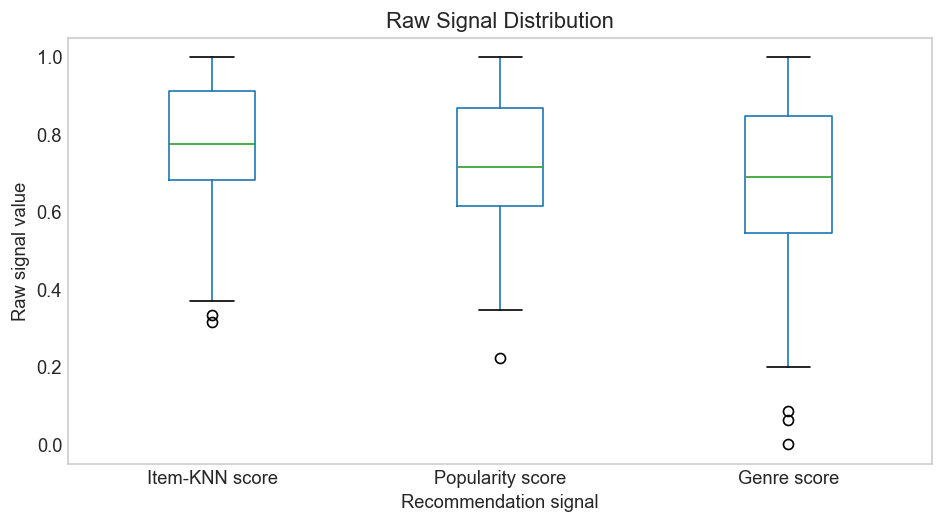

In [6]:
display(x.describe().T)
fig, ax = plt.subplots(figsize=(8, 4.5))

x.boxplot(ax=ax, grid=False)
ax.set_title("Raw Signal Distribution")
ax.set_xlabel("Recommendation signal")
ax.set_ylabel("Raw signal value")
plt.tight_layout()
plt.show()

The boxplots illustrate the distribution of the three recommendation signals before the hybrid weights are applied. All features exhibit relatively similar distributions, with median values concentrated between approximately 0.7 and 0.8. The Item-KNN score displays a slightly higher median, while the Genre score exhibits greater variability and a few low-value outliers. Overall, the three components operate on a comparable scale, allowing the weighting scheme to determine their relative influence on the final relevance score.

### Weighted Contribution Analysis

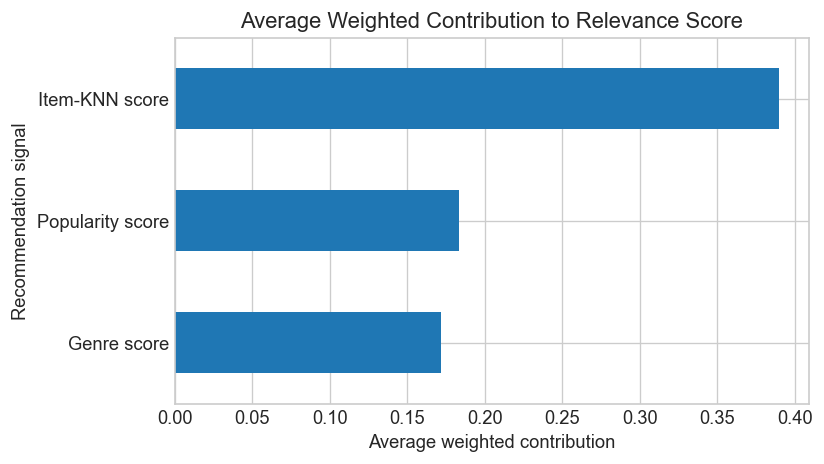

In [7]:
weighted_contributions = x.mul(weight_series, axis=1)
mean_contribution = weighted_contributions.mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
mean_contribution.plot(
    kind="barh",
    ax=ax,
)
ax.set_title("Average Weighted Contribution to Relevance Score")
ax.set_xlabel("Average weighted contribution")
ax.set_ylabel("Recommendation signal")

plt.tight_layout()
plt.show()

The bar chart shows the average weighted contribution of each recommendation signal to the final relevance score. Although the raw feature distributions are relatively similar, the Item-KNN component contributes substantially more because it receives a weight of 0.5, compared with 0.25 for both Popularity and Genre. As a result, collaborative filtering information has the strongest influence on the ranking process, while popularity and genre similarity act as complementary signals.

### SHAP Values

In [8]:
# Mean recommendation as the SHAP background.
background = x.mean().to_frame().T

explainer = shap.Explainer(
    predict_hybrid,
    background,
    feature_names=x.columns.tolist()
)

shap_values = explainer(x)

### Shap Summary Plot

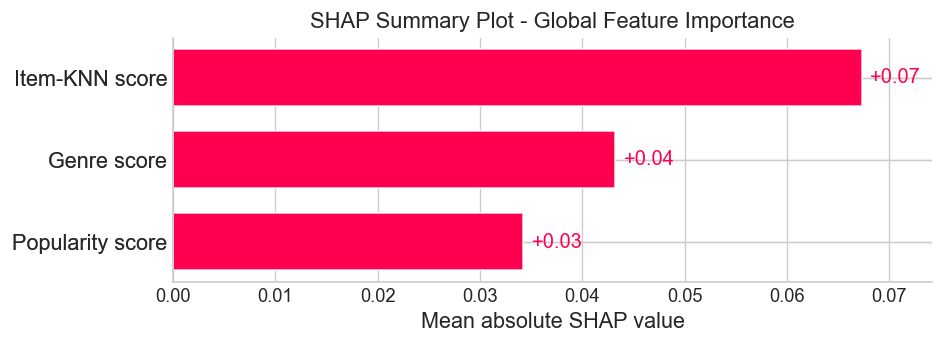

In [9]:
shap.plots.bar(
    shap_values,
    max_display=len(feature_cols),
    show=False
)

plt.title("SHAP Summary Plot - Global Feature Importance")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

The SHAP summary plot presents the mean absolute SHAP value of each feature across all recommendations, providing a measure of global feature importance. The Item-KNN score has the highest average impact on the final relevance score, followed by the Genre score and the Popularity score. This ranking is consistent with the weighting scheme of the hybrid recommender, where the Item-KNN component receives the largest weight. Consequently, collaborative filtering information contributes most strongly to variations in recommendation scores, while genre similarity and popularity provide additional but smaller effects.

### SHAP Beeswarm Plot

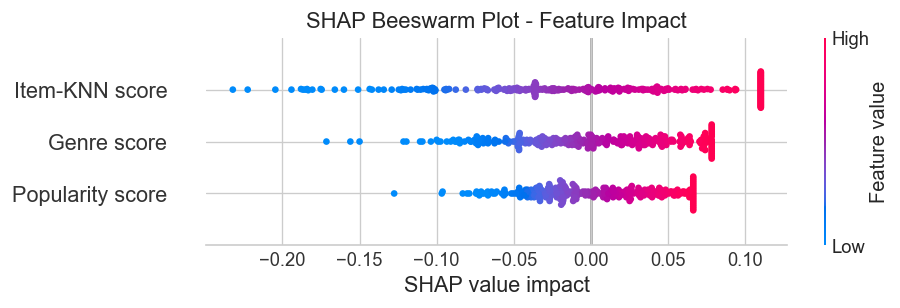

In [10]:
shap.plots.beeswarm(
    shap_values,
    max_display=len(feature_cols),
    show=False
)

plt.title("SHAP Beeswarm Plot - Feature Impact")
plt.xlabel("SHAP value impact")
plt.tight_layout()
plt.show()

The SHAP beeswarm plot shows both the magnitude and direction of each feature's contribution across individual recommendations. Higher feature values generally produce positive SHAP values, increasing the final relevance score, while lower values reduce it. The Item-KNN score exhibits the widest spread and therefore the strongest influence on recommendation outcomes, which is consistent with its larger weight in the hybrid model. However, the Genre score also displays substantial variability, indicating that genre similarity remains an important factor despite receiving a lower weight. In contrast, the Popularity score contributes more consistently and with a narrower range of impact.

### SHAP Waterfall Plots
#### Setup

In [15]:
def get_movie_genres(movie_id, movies_df):
    movie_row = movies_df.loc[movie_id]

    genres = [
        col
        for col in movies_df.columns
        if col != "title" and movie_row[col] == 1
    ]

    return ", ".join(genres)

#### High Recommendation

HIGH RECOMMENDATION

User ID: 8

Recommended Movie : Fight Club (1999)
Genres            : Action, Crime, Drama, Thriller
Number of Ratings : 218
Relevance Score   : 0.9938

Signal Scores
  Item-KNN   : 1.0000
  Popularity : 1.0000
  Genre      : 0.9753

Top Rated Movies of the User


,title,rating,genres
1058,True Lies (1994),5.0,"Action, Adventure, Comedy, Romance, Thriller"
1069,Dances with Wolves (1990),5.0,"Adventure, Drama, Western"
1051,"Shawshank Redemption, The (1994)",5.0,"Crime, Drama"
1039,"Net, The (1995)",5.0,"Action, Crime, Thriller"
1046,Interview with the Vampire: The Vampire Chroni...,5.0,"Drama, Horror"
1031,Babe (1995),5.0,"Children, Drama"
1055,"Lion King, The (1994)",5.0,"Adventure, Animation, Children, Drama, IMAX, M..."
1065,Schindler's List (1993),5.0,"Drama, War"
1034,"Usual Suspects, The (1995)",5.0,"Crime, Mystery, Thriller"
1054,Four Weddings and a Funeral (1994),5.0,"Comedy, Romance"



Most Common Genres in User Preferences


genres
Drama        6
Adventure    3
Thriller     3
Crime        3
Action       2
Comedy       2
Romance      2
Children     2
Western      1
Horror       1
Name: count, dtype: int64

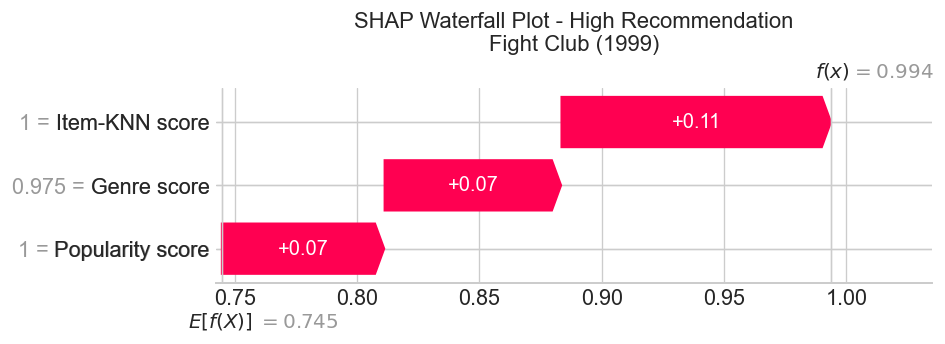

In [16]:
ratings = ranker.item_engine.df
movies = ranker.item_engine.movies

rating_counts = ratings.groupby("movieId").size()

high_idx = int(np.argmax(recommendations["computed_relevance_score"].values))

rec = recommendations.loc[high_idx]

user_id = rec["userId"]
movie_id = rec["movieId"]

# Top rated movies of the user
top_user_movies = (
    ratings[ratings["userId"] == user_id]
    .sort_values("rating", ascending=False)
    .head(10)
    .copy()
)

top_user_movies["title"] = top_user_movies["movieId"].map(
    movies["title"]
)

top_user_movies["genres"] = top_user_movies["movieId"].apply(
    lambda x: get_movie_genres(x, movies)
)

# Most common genres in the user's favourites
user_genres = (
    top_user_movies["genres"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

# Popularity
popularity_count = rating_counts.get(movie_id, 0)

print("HIGH RECOMMENDATION\n")

print(f"User ID: {user_id}\n")

print(f"Recommended Movie : {rec['title']}")
print(f"Genres            : {get_movie_genres(movie_id, movies)}")
print(f"Number of Ratings : {popularity_count}")
print(f"Relevance Score   : {rec['computed_relevance_score']:.4f}\n")

print("Signal Scores")
print(f"  Item-KNN   : {rec['item_knn_score']:.4f}")
print(f"  Popularity : {rec['popularity_score']:.4f}")
print(f"  Genre      : {rec['genre_score']:.4f}")

print("\nTop Rated Movies of the User")
display(top_user_movies[["title", "rating", "genres"]])

print("\nMost Common Genres in User Preferences")
display(user_genres)

shap.plots.waterfall(
    shap_values[high_idx],
    max_display=len(feature_cols),
    show=False
)
plt.title(f"SHAP Waterfall Plot - High Recommendation\n{rec['title']}")

plt.tight_layout()
plt.show()

* **High score recommendation:**
The waterfall plot for Fight Club (1999) explains how the recommendation score increases from the baseline value of 0.745 to a final score of 0.994. All three recommendation signals contribute positively, with the largest effect coming from the Item-KNN score. This result is consistent with the user's profile, as the user's highly rated movies and dominant genres (Drama, Crime and Thriller) closely match the characteristics of the recommended movie. Together with its strong popularity score, these factors lead to an exceptionally high recommendation score.

#### Low Recommendation

LOW RECOMMENDATION

User ID: 26

Recommended Movie : Wolf of Wall Street, The (2013)
Genres            : Comedy, Crime, Drama
Number of Ratings : 54
Relevance Score   : 0.5173

Signal Scores
  Item-KNN   : 0.4033
  Popularity : 0.7728
  Genre      : 0.4899

Top Rated Movies of the User


,title,rating,genres
4048,Pulp Fiction (1994),4.0,"Comedy, Crime, Drama, Thriller"
4057,Batman (1989),4.0,"Action, Crime, Thriller"
4058,"Silence of the Lambs, The (1991)",4.0,"Crime, Horror, Thriller"
4056,"Fugitive, The (1993)",4.0,Thriller
4043,Die Hard: With a Vengeance (1995),4.0,"Action, Crime, Thriller"
4055,"Firm, The (1993)",4.0,"Drama, Thriller"
4040,Seven (a.k.a. Se7en) (1995),4.0,"Mystery, Thriller"
4041,Apollo 13 (1995),3.0,"Adventure, Drama, IMAX"
4053,True Lies (1994),3.0,"Action, Adventure, Comedy, Romance, Thriller"
4042,Batman Forever (1995),3.0,"Action, Adventure, Comedy, Crime"



Most Common Genres in User Preferences


genres
Thriller     8
Crime        5
Action       4
Comedy       3
Drama        3
Adventure    3
Horror       1
Mystery      1
IMAX         1
Romance      1
Name: count, dtype: int64

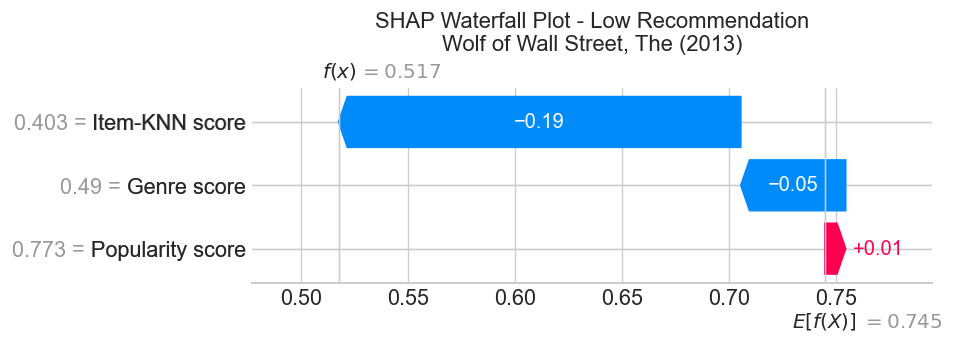

In [17]:
ratings = ranker.item_engine.df
movies = ranker.item_engine.movies

rating_counts = ratings.groupby("movieId").size()

low_idx = int(np.argmin(recommendations["computed_relevance_score"].values))

rec = recommendations.loc[low_idx]

user_id = rec["userId"]
movie_id = rec["movieId"]

# Top rated movies of the user
top_user_movies = (
    ratings[ratings["userId"] == user_id]
    .sort_values("rating", ascending=False)
    .head(10)
    .copy()
)

top_user_movies["title"] = top_user_movies["movieId"].map(
    movies["title"]
)

top_user_movies["genres"] = top_user_movies["movieId"].apply(
    lambda x: get_movie_genres(x, movies)
)

# Most common genres in the user's favourites
user_genres = (
    top_user_movies["genres"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

# Popularity
popularity_count = rating_counts.get(movie_id, 0)

print("LOW RECOMMENDATION\n")

print(f"User ID: {user_id}\n")

print(f"Recommended Movie : {rec['title']}")
print(f"Genres            : {get_movie_genres(movie_id, movies)}")
print(f"Number of Ratings : {popularity_count}")
print(f"Relevance Score   : {rec['computed_relevance_score']:.4f}\n")

print("Signal Scores")
print(f"  Item-KNN   : {rec['item_knn_score']:.4f}")
print(f"  Popularity : {rec['popularity_score']:.4f}")
print(f"  Genre      : {rec['genre_score']:.4f}")

print("\nTop Rated Movies of the User")
display(top_user_movies[["title", "rating", "genres"]])

print("\nMost Common Genres in User Preferences")
display(user_genres)


shap.plots.waterfall(
    shap_values[low_idx],
    max_display=len(feature_cols),
    show=False
)

plt.title(f"SHAP Waterfall Plot - Low Recommendation\n{rec['title']}")

plt.tight_layout()
plt.show()

* **Low score recommendation:**
The waterfall plot for The Wolf of Wall Street (2013) shows how the final score decreases from the baseline value of 0.745 to 0.517. The main negative contribution comes from the Item-KNN score, while the Genre score also reduces the prediction. Although the movie shares some genres with the user's preferences and benefits from a relatively strong popularity signal, it appears less similar to the user's previously preferred movies in the collaborative filtering space. As a result, the recommendation remains relevant but receives a substantially lower ranking than the highest-scoring recommendations.

### Conclusion
Overall, the SHAP analysis provides a transparent decomposition of the hybrid relevance score by quantifying the contribution of each recommendation signal to the final prediction. The results show that Item-KNN contributes the most to score variations, followed by genre similarity and popularity. However, because the hybrid ranker is based on a predefined weighted linear combination of features, the SHAP values primarily reflect how each signal contributes to the final score rather than revealing complex relationships or interactions between features. Therefore, in this context, SHAP serves mainly as an explanation tool for the ranking decisions, offering both global and local interpretability of recommendations, rather than uncovering previously unknown feature dependencies.